# 1 — Value-at-Risk, Expected Shortfall, and whether the model is any good

Value-at-Risk answers "how much can we lose on a bad day?". It is easy to
compute and easy to compute *wrongly*, so this notebook does two things:

1. Estimates 99% VaR and Expected Shortfall six different ways.
2. **Backtests** them — because a VaR number nobody has validated is decoration.

All logic lives in the `risk_engine` package (118 tests). This notebook is the
narrative layer.

In [1]:
from risk_engine import (
    load_prices, to_returns, portfolio_returns,
    historical_var, parametric_var, monte_carlo_var,
    rolling_var_backtest,
)
from risk_engine.report import results_table, plot_return_distribution, plot_var_backtest

TICKERS = ["AAPL", "MSFT", "GOOGL", "JPM", "XOM"]

prices = load_prices(TICKERS, start="2018-01-01")
returns = to_returns(prices)
pnl = portfolio_returns(returns)          # equal-weight, daily rebalanced

print(f"{len(pnl)} observations, {pnl.index[0].date()} to {pnl.index[-1].date()}")
returns.describe().T[["mean", "std", "min", "max"]]

2160 observations, 2018-01-03 to 2026-08-07


,mean,std,min,max
AAPL,0.001136,0.019273,-0.128647,0.153289
MSFT,0.001025,0.018399,-0.147390,0.155067
GOOGL,0.001071,0.019657,-0.116342,0.102244
JPM,0.000826,0.018081,-0.149649,0.180125
XOM,0.000627,0.018941,-0.122248,0.126868


### Annualised volatility and fat tails

Before estimating anything, look at the shape of the data. Excess kurtosis well
above zero means the normal distribution is the wrong model for the tail — and
that single fact drives most of what follows.

In [2]:
import numpy as np
from scipy import stats

summary = returns.agg(["mean", "std"]).T
summary["annual_vol"] = summary["std"] * np.sqrt(252)
summary["skew"] = returns.skew()
summary["excess_kurtosis"] = returns.kurtosis()   # 0 for a normal distribution
summary.round(4)

,mean,std,annual_vol,skew,excess_kurtosis
AAPL,0.0011,0.0193,0.3060,0.1152,6.2898
MSFT,0.0010,0.0184,0.2921,0.2803,8.3152
GOOGL,0.0011,0.0197,0.3120,0.0507,3.8260
JPM,0.0008,0.0181,0.2870,0.3077,13.2285
XOM,0.0006,0.0189,0.3007,-0.0248,5.1783


## Six estimates of the same number

| Method | Assumption it relaxes |
|---|---|
| Historical | none — pure empirical quantile |
| Parametric normal | returns are Gaussian |
| Parametric Student-t | Gaussian body, fat tails |
| Monte Carlo (gaussian) | *control* — must reproduce parametric normal |
| Monte Carlo (Student-t) | fat tails **plus** the correlation structure |
| Monte Carlo (bootstrap) | no distribution at all; resamples whole dates |

The Monte Carlo engines simulate the **asset vector** through a Cholesky factor
of the covariance matrix, not a fitted portfolio sigma. That distinction
matters: sampling from `N(mu_p, sigma_p)` fitted to the portfolio series just
reproduces the parametric answer with extra noise.

In [3]:
CONF = 0.99

results = [
    historical_var(pnl, CONF),
    parametric_var(pnl, CONF, distribution="normal"),
    parametric_var(pnl, CONF, distribution="student_t"),
    monte_carlo_var(returns, confidence=CONF, engine="gaussian"),
    monte_carlo_var(returns, confidence=CONF, engine="student_t"),
    monte_carlo_var(returns, confidence=CONF, engine="bootstrap"),
]

table = results_table(results)
table[["method", "VaR", "ES", "detail"]].style.format({"VaR": "{:.4%}", "ES": "{:.4%}"})

,method,VaR,ES,detail
0,historical,3.9127%,5.4015%,empirical quantile
1,parametric_normal,3.1598%,3.6338%,"normal(mu=0.000937, sigma=0.013986)"
2,parametric_student_t,3.7111%,5.7167%,"student_t(df=3.10, loc=0.001373, scale=0.008688)"
3,monte_carlo_gaussian,3.1628%,3.6194%,multivariate normal via Cholesky
4,monte_carlo_student_t,3.6401%,5.5654%,multivariate student-t (df=3.13) via Cholesky
5,monte_carlo_bootstrap,3.9318%,5.5730%,iid bootstrap of historical dates


**Read the gap.** The normal model reports the smallest loss of the six, and its
Expected Shortfall is further below the historical figure than its VaR is —
because ES integrates the whole tail, which is exactly where the normal
assumption breaks down.

The spread between methods is *model risk*. It is not noise to be averaged away;
it is the reason more than one method gets run.

VaR spread across methods: 0.7720% (24.4% of the smallest estimate)


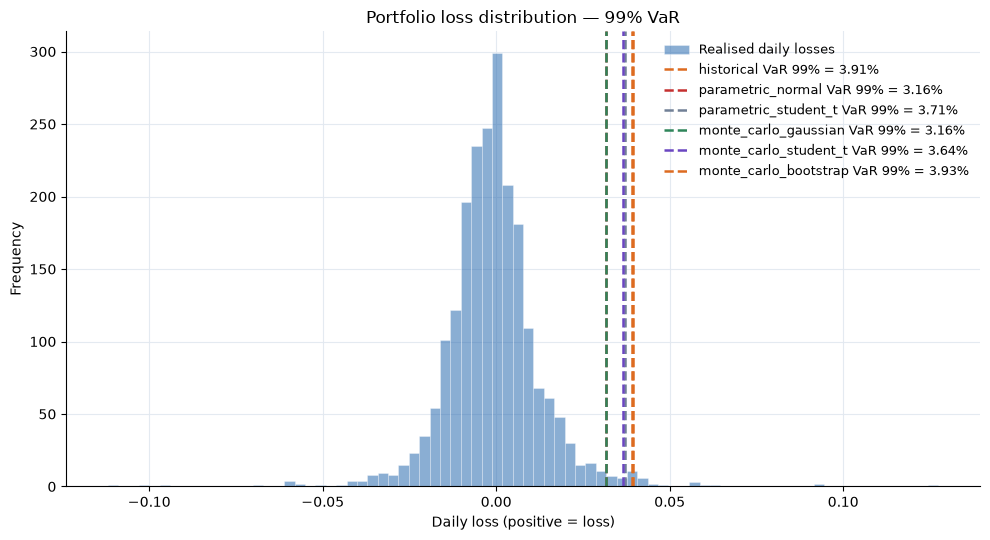

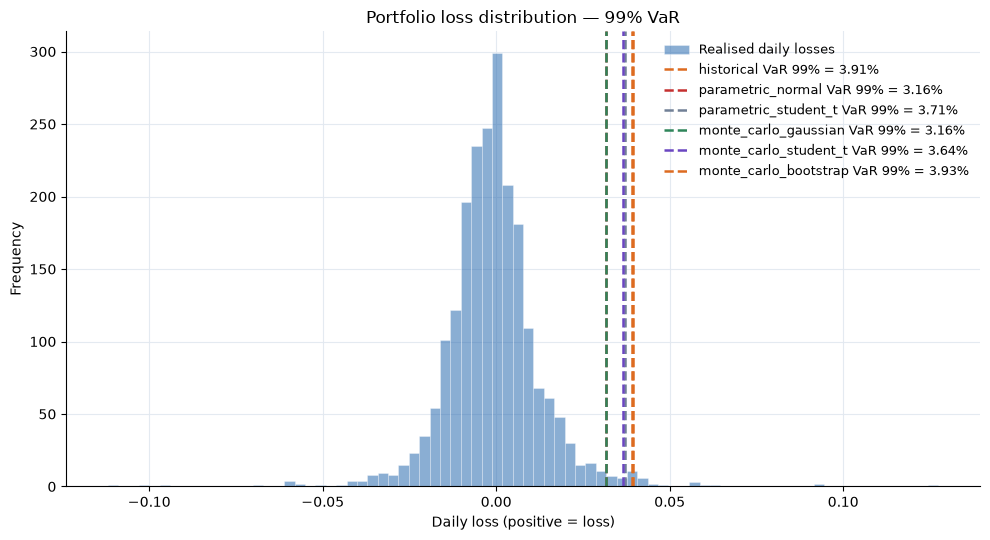

In [4]:
spread = table["VaR"].max() - table["VaR"].min()
print(f"VaR spread across methods: {spread:.4%} "
      f"({spread / table['VaR'].min():.1%} of the smallest estimate)")

fig = plot_return_distribution(pnl, results, title="Portfolio loss distribution — 99% VaR")
fig

## The part that actually matters: backtesting

Counting breaches is not a backtest. Three questions have to be answered:

1. **Unconditional coverage** — is the breach rate distinguishable from 1%?
   *Kupiec (1995) proportion-of-failures test.*
2. **Independence** — do breaches cluster? Clustering means the model is blind
   to volatility regimes even when the total count looks acceptable.
   *Christoffersen (1998).*
3. **Conditional coverage** — the joint test.

Every forecast uses only the 250 days strictly before it. An in-sample VaR is
guaranteed to look well-calibrated and proves nothing.

In [5]:
backtests = {}
for method in ("historical", "parametric_normal", "parametric_t"):
    bt = rolling_var_backtest(pnl, confidence=CONF, window=250, method=method)
    backtests[method] = bt
    print(bt.summary())
    print()

Model            : historical
Confidence       : 99.0%   rolling window: 250d
Out-of-sample    : 1910 days
Breaches         : 34 (1.78% observed vs 1.00% expected)
Basel zone       : AMBER (34 breaches) — model under review

Kupiec (unconditional)       LR=  9.531  p=0.0020  [REJECT]
Christoffersen (independence) LR=  5.167  p=0.0230  [REJECT]
Conditional coverage (joint) LR= 14.699  p=0.0006  [REJECT]

Model            : parametric_normal
Confidence       : 99.0%   rolling window: 250d
Out-of-sample    : 1910 days
Breaches         : 48 (2.51% observed vs 1.00% expected)
Basel zone       : RED (48 breaches) — model rejected

Kupiec (unconditional)       LR= 31.109  p=0.0000  [REJECT]
Christoffersen (independence) LR= 10.688  p=0.0011  [REJECT]
Conditional coverage (joint) LR= 41.797  p=0.0000  [REJECT]



Model            : parametric_t
Confidence       : 99.0%   rolling window: 250d
Out-of-sample    : 1910 days
Breaches         : 38 (1.99% observed vs 1.00% expected)
Basel zone       : RED (38 breaches) — model rejected

Kupiec (unconditional)       LR= 14.670  p=0.0001  [REJECT]
Christoffersen (independence) LR=  7.424  p=0.0064  [REJECT]
Conditional coverage (joint) LR= 22.094  p=0.0000  [REJECT]



### Interpreting the verdict

A rejection is a **finding, not a bug**. The sample spans the COVID crash and
the 2022 drawdown; unconditional models struggle with it.

Two things to notice:

- The Student-t model breaches *less* than the normal one, confirming the
  fat-tail diagnosis from the kurtosis table above.
- Its breaches still **cluster** (Christoffersen rejects). Fat tails were not
  the only problem — volatility is time-varying, and none of these models track
  it.

The clustering is the actionable signal, and the next section acts on it.

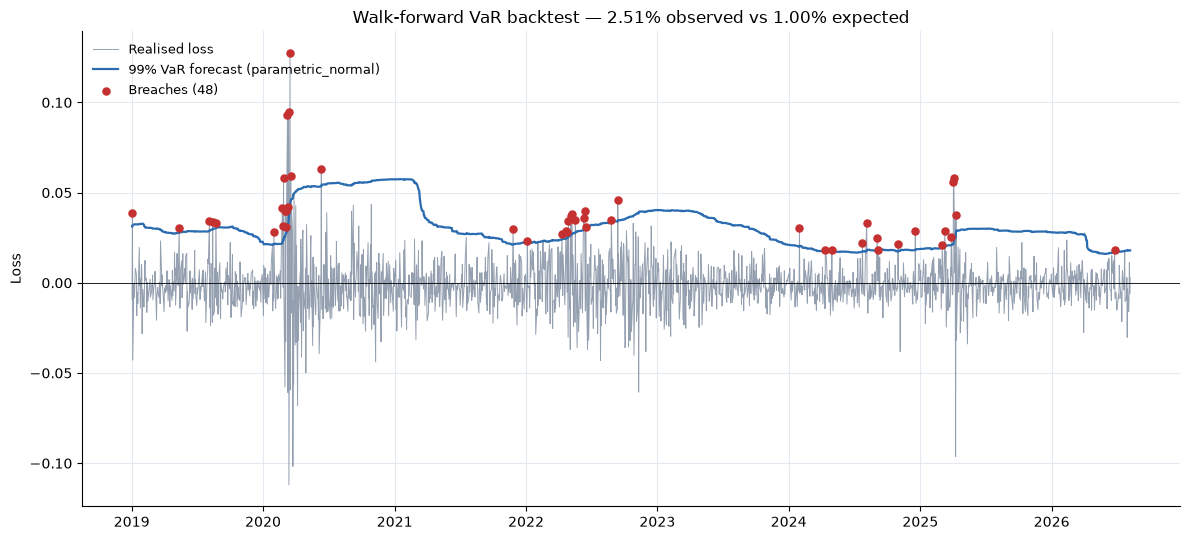

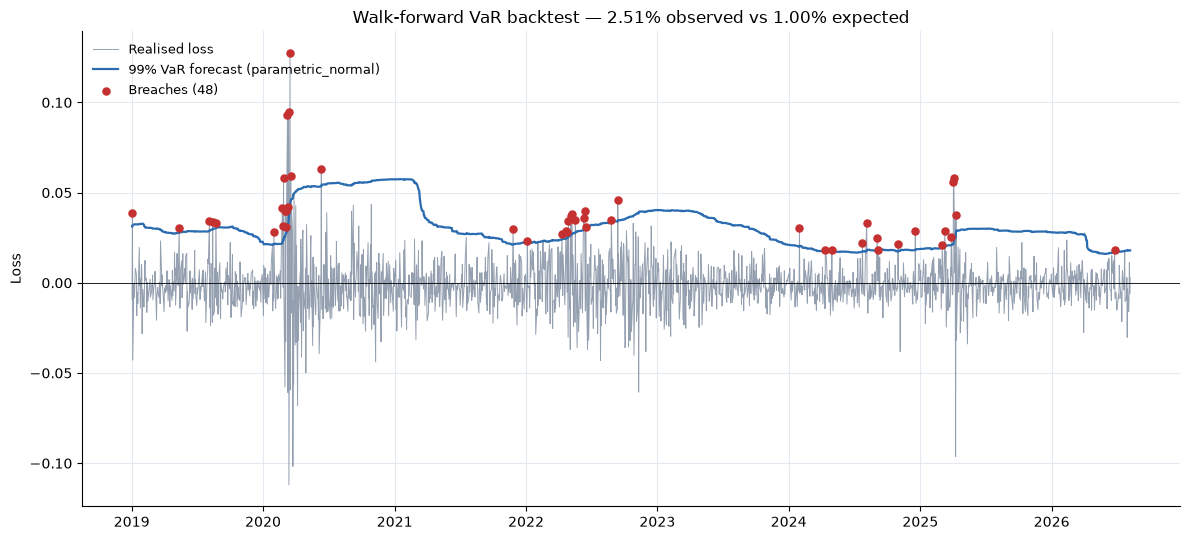

In [6]:
fig = plot_var_backtest(backtests["parametric_normal"])
fig

In [7]:
# Breach clustering, made visible: the COVID period concentrates the failures.
bt = backtests["parametric_normal"]
breach_dates = bt.breaches[bt.breaches == 1].index
print(f"{len(breach_dates)} breaches; by year:")
breach_dates.to_series().groupby(breach_dates.year).size()

48 breaches; by year:


Date
2019     5
2020    13
2021     1
2022    13
2024     9
2025     6
2026     1
Name: Date, dtype: int64

## Expected Shortfall, and why regulators moved to it

VaR says *how bad a 1-in-100 day is*. It says nothing about the 1-in-500 day.
ES averages the entire tail beyond VaR, which is why Basel's FRTB replaced VaR
with ES at 97.5% as the capital measure.

ES is also **coherent**: it is sub-additive, so combining two portfolios can
never increase it. VaR can violate that, which makes it a poor tool for
allocating risk limits across desks.

In [8]:
import pandas as pd

rows = []
for conf in (0.95, 0.975, 0.99):
    h = historical_var(pnl, conf)
    rows.append({"confidence": f"{conf:.1%}", "VaR": h.var, "ES": h.expected_shortfall,
                 "ES/VaR": h.expected_shortfall / h.var})
pd.DataFrame(rows).style.format({"VaR": "{:.4%}", "ES": "{:.4%}", "ES/VaR": "{:.2f}x"})

,confidence,VaR,ES,ES/VaR
0,95.0%,2.0166%,3.2856%,1.63x
1,97.5%,2.8559%,4.1883%,1.47x
2,99.0%,3.9127%,5.4015%,1.38x


## Multi-day horizons

Regulatory capital uses a 10-day horizon. The square-root-of-time rule scales a
1-day figure by `sqrt(h)` — valid only for iid returns with no autocorrelation.

Given that the backtests above found **clustered** breaches, that assumption is
known to be violated here, so the 10-day number understates risk. The engine
applies the rule because it is the convention, and records the caveat in the
result's `detail` field rather than hiding it.

In [9]:
for h in (1, 5, 10):
    r = historical_var(pnl, 0.99, horizon_days=h)
    print(f"{h:2d}-day 99% VaR: {r.var:.4%}   ES: {r.expected_shortfall:.4%}")

 1-day 99% VaR: 3.9127%   ES: 5.4015%
 5-day 99% VaR: 8.7490%   ES: 12.0782%
10-day 99% VaR: 12.3730%   ES: 17.0812%


---

# Acting on the diagnosis: a volatility filter

The independence test told us precisely what is missing — the models treat
volatility as constant. So forecast it instead.

Two filters, both in `risk_engine.volatility`:

- **EWMA** — RiskMetrics' exponentially weighted moving average, `lambda = 0.94`.
  One fixed parameter, nothing to estimate, so it cannot overfit.
- **GARCH(1,1)** — fitted by maximum likelihood. Strictly more general, with a
  mean-reverting long-run variance that EWMA lacks.

Then take the tail quantile from the **standardised residuals** `z = r / sigma`
rather than from a normal. That is **Filtered Historical Simulation**, and the
division of labour is the point: the filter handles clustering, the empirical
residual quantile handles fat tails, and neither has to model the other.

In [10]:
from risk_engine.volatility import fit_garch11, garch_variance, standardised_residuals

params = fit_garch11(pnl)
print(params)
print(f"long-run daily volatility : {np.sqrt(params.long_run_variance):.4%}")
print(f"shock half-life           : {params.half_life:.1f} trading days")

GARCH(1,1) omega=5.363e-06 alpha=0.1134 beta=0.8532 persistence=0.9666 half-life=20.4d
long-run daily volatility : 1.2665%
shock half-life           : 20.4 trading days


Persistence near 1 is the quantitative statement of volatility clustering: a
shock today still moves the variance weeks later. The half-life makes that
concrete.

Does the filter work? The standard diagnostic is autocorrelation of *squared*
returns. If the filter has done its job, the squared standardised residuals
should show far less of it.

In [11]:
z = standardised_residuals(pnl.to_numpy(), garch_variance(pnl, params))

def lag1(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    return float(np.corrcoef(x[:-1], x[1:])[0, 1])

print(f"lag-1 autocorrelation of squared returns  : {lag1(pnl.to_numpy()**2): .4f}")
print(f"lag-1 autocorrelation of squared residuals: {lag1(z**2): .4f}")
print(f"\nresidual std dev: {z.std(ddof=1):.4f} (should be near 1)")
print(f"residual excess kurtosis: {pd.Series(z).kurtosis():.2f} "
      "(what remains is genuine tail behaviour, not a volatility artefact)")

lag-1 autocorrelation of squared returns  :  0.4719
lag-1 autocorrelation of squared residuals:  0.0036

residual std dev: 0.9998 (should be near 1)
residual excess kurtosis: 1.63 (what remains is genuine tail behaviour, not a volatility artefact)


## The comparison that matters

`compare_models` backtests every model and sorts by the joint conditional-coverage
p-value — highest first, i.e. the model the data argues against least.

In [12]:
from risk_engine.backtest import compare_models

comparison = compare_models(pnl, confidence=CONF, window=250)
comparison.style.format({
    "breach_rate": "{:.2%}", "expected_rate": "{:.2%}", "mean_var": "{:.3%}",
    "kupiec_p": "{:.4f}", "christoffersen_p": "{:.4f}", "joint_p": "{:.4f}",
})

,method,breaches,breach_rate,expected_rate,kupiec_p,christoffersen_p,joint_p,passes_all,basel,mean_var
0,ewma_fhs,32,1.68%,1.00%,0.0068,0.2962,0.0149,False,AMBER,3.432%
1,garch_fhs,34,1.78%,1.00%,0.0020,0.1464,0.0030,False,AMBER,3.047%
2,historical,34,1.78%,1.00%,0.0020,0.0230,0.0006,False,AMBER,3.355%
3,ewma_normal,38,1.99%,1.00%,0.0001,0.7851,0.0006,False,RED,2.877%
4,parametric_t,38,1.99%,1.00%,0.0001,0.0064,0.0000,False,RED,3.619%
5,parametric_normal,48,2.51%,1.00%,0.0000,0.0011,0.0000,False,RED,3.055%


**Read the Christoffersen column.** Every volatility-filtered model clears it;
every unconditional one fails. The clustering that diagnosed the problem is gone.

Coverage at 99% is still too thin for all of them — that tail is genuinely hard.
So run it again at **97.5%**, the level Basel FRTB actually uses for its capital
measure.

In [13]:
comparison_975 = compare_models(pnl, confidence=0.975, window=250)
comparison_975.style.format({
    "breach_rate": "{:.2%}", "expected_rate": "{:.2%}", "mean_var": "{:.3%}",
    "kupiec_p": "{:.4f}", "christoffersen_p": "{:.4f}", "joint_p": "{:.4f}",
})

,method,breaches,breach_rate,expected_rate,kupiec_p,christoffersen_p,joint_p,passes_all,basel,mean_var
0,ewma_fhs,61,3.19%,2.50%,0.0624,0.9701,0.1761,True,AMBER,2.696%
1,historical,65,3.40%,2.50%,0.0165,0.2606,0.0299,False,AMBER,2.562%
2,garch_fhs,68,3.56%,2.50%,0.0052,0.7099,0.0189,False,AMBER,2.452%
3,ewma_normal,67,3.51%,2.50%,0.0078,0.1160,0.0084,False,AMBER,2.424%
4,parametric_t,66,3.46%,2.50%,0.0114,0.0018,0.0003,False,AMBER,2.564%
5,parametric_normal,67,3.51%,2.50%,0.0078,0.0023,0.0003,False,AMBER,2.559%


In [14]:
winners = comparison_975[comparison_975["passes_all"]]
if len(winners):
    for _, row in winners.iterrows():
        print(f"PASSES ALL THREE TESTS: {row['method']}  "
              f"(Kupiec p={row['kupiec_p']:.4f}, "
              f"Christoffersen p={row['christoffersen_p']:.4f}, "
              f"joint p={row['joint_p']:.4f})")
else:
    print("No model passes all three at 97.5%.")

PASSES ALL THREE TESTS: ewma_fhs  (Kupiec p=0.0624, Christoffersen p=0.9701, joint p=0.1761)


## What this exercise actually demonstrates

The volatility-filtered model is the only one that survives the full battery at
the regulatory confidence level — and it exists **because** the earlier models
failed in a specific, readable way.

That is the argument for backtesting properly. A breach count alone would have
said "the model is wrong". The independence test said *why*, and that pointed
directly at the fix.

Two things I would not claim:

- **99% coverage is still unsolved here.** No model on this data achieves it.
  Extreme value theory — fitting a generalised Pareto tail to the residuals
  above a threshold — is the standard next move, and the framework in this
  repository is what would test whether it worked.
- **EWMA beating GARCH is not a general result.** On this sample, with GARCH
  refit every 25 steps, the simpler filter wins. That ordering could easily
  reverse on other data or with daily refitting, and I have not tested that.

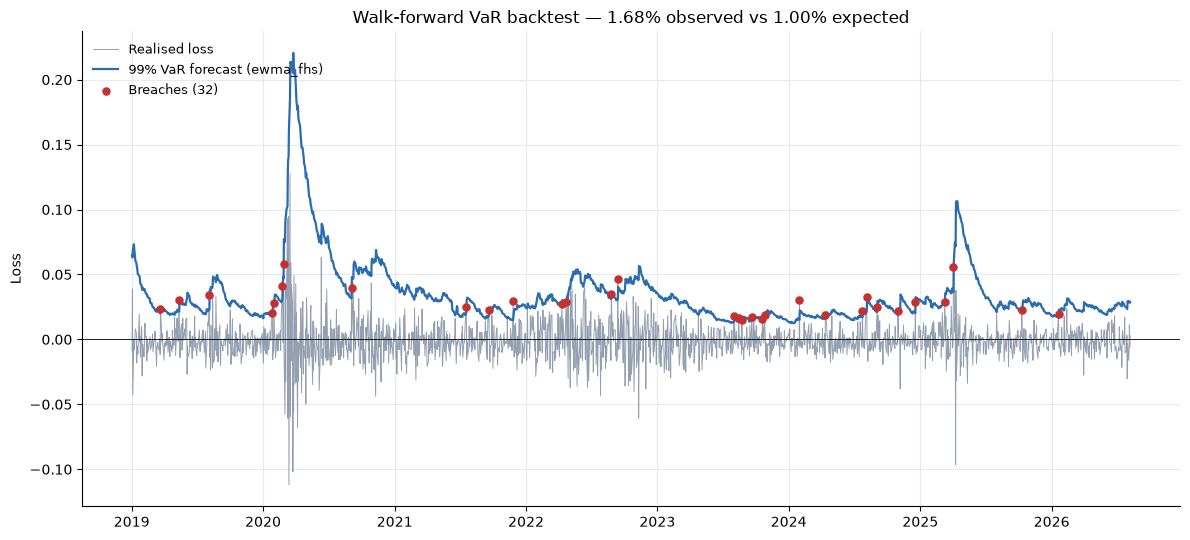

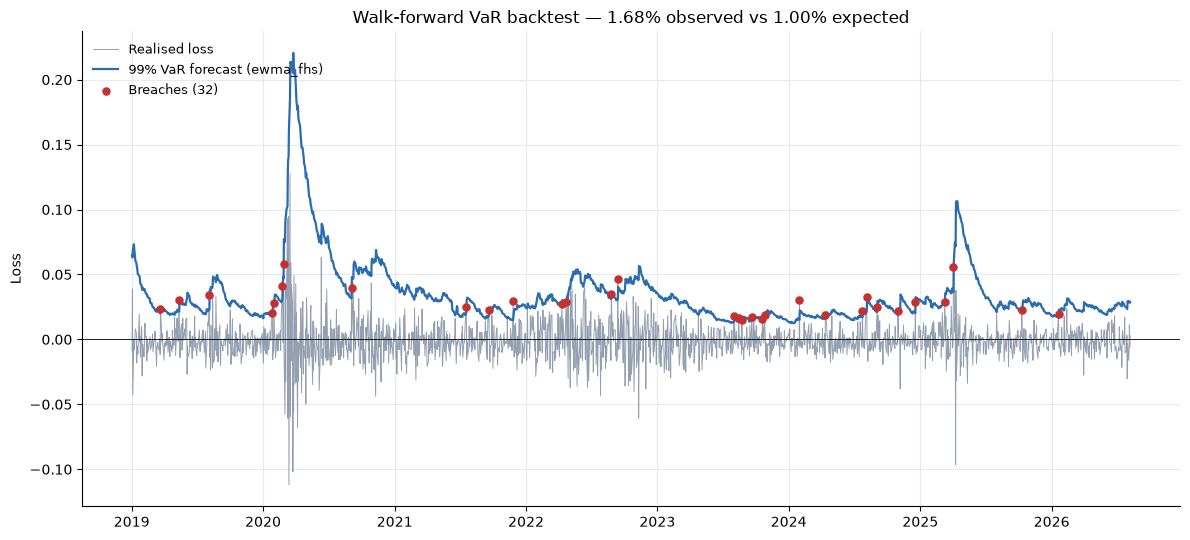

In [15]:
fig = plot_var_backtest(rolling_var_backtest(pnl, CONF, 250, "ewma_fhs"))
fig